In [1]:
import numpy as np
import matplotlib.pyplot as plt
import capytaine as cpt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### Load in Mesh

In [2]:
buoy_mesh = cpt.load_mesh("Buoy.STL")

### Init Floating Body + Add DoF
converts the static 3D mesh into a mathematical boundary condition that the fluid solver can interact with. By wrapping it in `FloatingBody`, Capytaine automatically assigns the 6 Degrees of Freedom (DOFs) to the object, defining exactly how it can move when hit by waves:

**Translations (Linear Movement):**
* **Surge:** Forward/backward (X-axis)
* **Sway:** Left/right (Y-axis)
* **Heave:** Up/down (Z-axis)

**Rotations (Angular Movement):**
* **Roll:** Tilting side-to-side (around X-axis)
* **Pitch:** Tilting forward/backward (around Y-axis)
* **Yaw:** Spinning (around Z-axis)

In [3]:
buoy = cpt.FloatingBody( 
    mesh=buoy_mesh,
    name="buoy"
)
buoy.add_all_rigid_body_dofs()

[10:10:26] WARNING  The rotation dof Roll has been initialized around the origin of the domain (0, 0, 0).

           WARNING  The rotation dof Pitch has been initialized around the origin of the domain (0, 0, 0).

           WARNING  The rotation dof Yaw has been initialized around the origin of the domain (0, 0, 0).

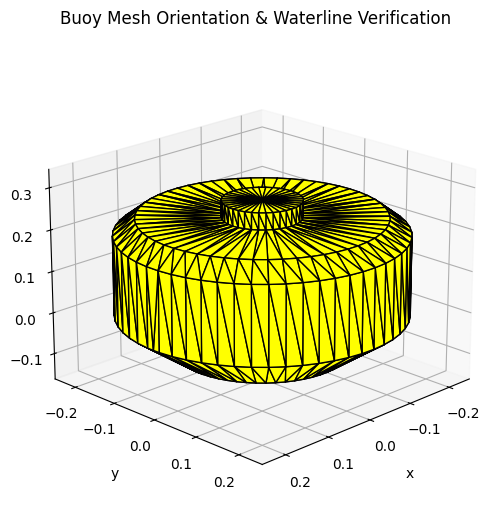

In [4]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_axis_on() 
ax.grid(True)
ax.set_xlabel('X Axis (Meters)', fontsize=10, labelpad=10)
ax.set_ylabel('Y Axis (Meters)', fontsize=10, labelpad=10)
ax.set_zlabel('Z Axis (Meters - VERTICAL)', fontsize=10, labelpad=10)
ax.view_init(elev=20, azim=45)
buoy.show_matplotlib(ax=ax)
plt.title("Buoy Mesh Orientation & Waterline Verification", fontsize=12, pad=20)
plt.show()

In [5]:
# Print the RAW bounding box to see CAD origin 
print(f"RAW Mesh Bounding Box (Min x, y, z): {buoy.mesh.vertices.min(axis=0)} meters") #shold see some negative
print(f"RAW Mesh Bounding Box (Max x, y, z): {buoy.mesh.vertices.max(axis=0)} meters")
print(f"num faces: {buoy.mesh.nb_faces}")

RAW Mesh Bounding Box (Min x, y, z): [-0.25315484 -0.25305873 -0.091     ] meters
RAW Mesh Bounding Box (Max x, y, z): [0.25315484 0.25305873 0.27140078] meters
num faces: 604


### Extract the Wetted Surface
The boundary element solver only calculates pressure on the physical area where water touches the hull. This step slices off the dry portion above Z=0. Make sure you put a lid on it!

In [19]:
# Extract only the wetted surface (everything below z=0)
submerged_body = buoy.immersed_part()

# Generate a flat lid mesh at the waterline (z=0.0) based on the sliced hull
lid_mesh = submerged_body.mesh.generate_lid(z=0.0)

buoy = cpt.FloatingBody(
    mesh=submerged_body.mesh,
    lid_mesh=lid_mesh,
    dofs=submerged_body.dofs
)

# Verify it cut correctly (Max z should now be 0.0)
print(f"Wet Mesh Bounding Box (Min x, y, z): {buoy.mesh.vertices.min(axis=0)} meters")
print(f"Wet Mesh Bounding Box (Max x, y, z): {buoy.mesh.vertices.max(axis=0)} meters")

Wet Mesh Bounding Box (Min x, y, z): [-0.25005163 -0.2499567  -0.091     ] meters
Wet Mesh Bounding Box (Max x, y, z): [2.50051630e-01 2.49956695e-01 4.33680869e-19] meters


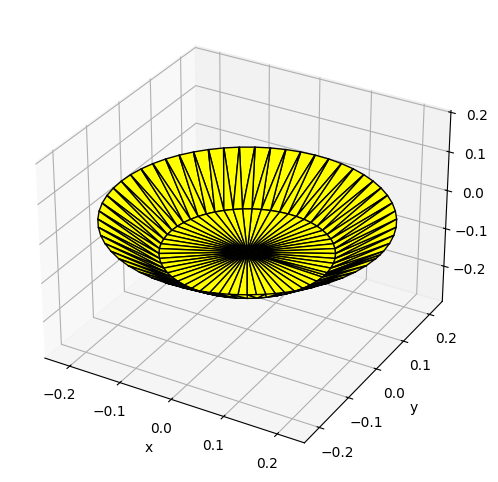

In [18]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

# Direct Capytaine plotting with zero extra options
buoy.mesh.show_matplotlib(ax=ax)
#buoy.lid_mesh.show_matplotlib(ax=ax)

plt.show()

### Define the Environment & Build the Task Queue
build a queue of tasks containing specific scenarios for the physics engine to solve. Each task bundles the buoy geometry together with specific environmental conditions. 

Assumptions:
* **Depth:** Infinite (representing deep open water).
* **Wave Angle:** **0°** (only one angle is needed since the buoy is perfectly symmetrical).
* **Frequency:** A single frequency from our massive sweep of 300 data points (0.1 rad/s to 15.0 rad/s).

Generates the tasks by looping through the frequencies.

*Note: high resolution and wide sweep are required for WEC-Sim. makes Impulse Response Function (IRF) clean*

In [8]:
# Generate a high-resolution array of 200 wave frequencies (rad/s)
omega_range = np.linspace(0.1, 15.0, 200)

tasks = []

# Build the task queue for both Radiation and Diffraction
for w in omega_range:
    
    for dof in buoy.dofs:
        tasks.append(
            cpt.RadiationProblem(
                body=buoy, 
                omega=w, 
                radiating_dof=dof,
                water_depth=np.inf
            )
        )
    
    tasks.append(
        cpt.DiffractionProblem(
            body=buoy, 
            omega=w, 
            wave_direction=0.0,
            water_depth=np.inf
        )
    )

# Verify the setup
print(f"Generated {len(tasks)} high-resolution test conditions.")

Generated 1400 high-resolution test conditions.


### Run the BEM Solver
processes our queue of tasks. For every frequency in the queue, the solver computes the core hydrodynamic forces acting on the wetted hull. 

The solver outputs a `results` dataset containing the foundational physics data required by WEC-Sim. The output is divided into two primary categories:

* **Radiation Data (Buoy moving in still water):**
    * **Added Mass:** The virtual weight added to the system as the buoy drags surrounding water along with its movement.
    * **Radiation Damping:** The energy the buoy loses to the environment by generating its own surface ripples as it oscillates.
* **Diffraction & Excitation Data (Waves hitting a stationary buoy):**
    * **Excitation Force:** The total hydrodynamic force exerted on the hull by incoming waves.
    * **Froude-Krylov Force:** The raw pressure exerted by the undisturbed wave profile.
    * **Diffraction Force:** The additional force generated as the waves bend, scatter, and distort around the physical hull.

In [9]:
# init the solver
solver = cpt.BEMSolver()

results = solver.solve_all(tasks)

print(f"Successfully computed {len(results)} hydrodynamic results")

           WARNING  Mesh resolution for 581 problems:                                                              
                    The resolution of the mesh might be insufficient for omega ranging from 8.860 to 15.000.       
                    This warning appears when the largest panel of this mesh has radius > wavelength/8.

Output()

Successfully computed 1400 hydrodynamic results


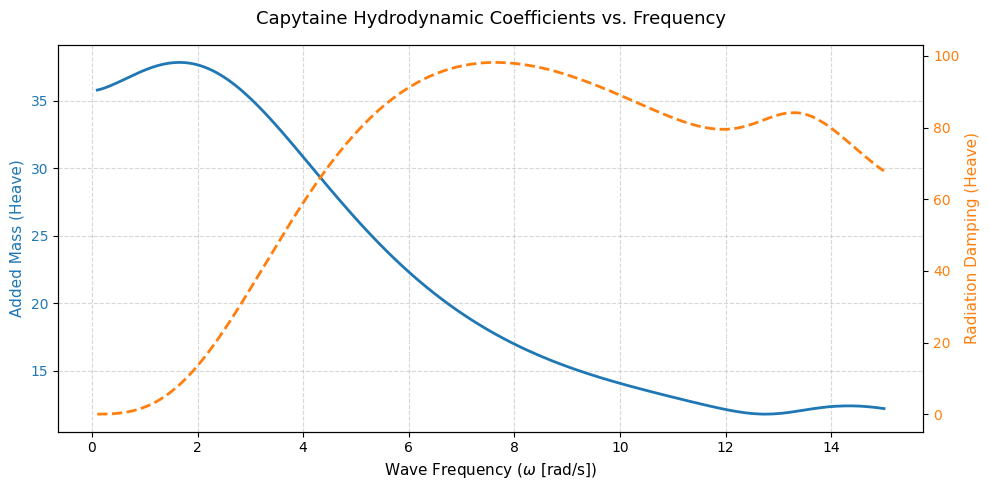

In [10]:
plot_ds = cpt.assemble_dataset(results)

omega_vals = plot_ds.coords['omega'].values

added_mass_heave = plot_ds['added_mass'].sel(radiating_dof='Heave', influenced_dof='Heave').values
damping_heave = plot_ds['radiation_damping'].sel(radiating_dof='Heave', influenced_dof='Heave').values

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel(r'Wave Frequency ($\omega$ [rad/s])', fontsize=11)
ax1.set_ylabel('Added Mass (Heave)', color=color, fontsize=11)
ax1.plot(omega_vals, added_mass_heave, color=color, linewidth=2, label='Added Mass')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Radiation Damping (Heave)', color=color, fontsize=11)
ax2.plot(omega_vals, damping_heave, color=color, linewidth=2, linestyle='--', label='Radiation Damping')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Capytaine Hydrodynamic Coefficients vs. Frequency', fontsize=13, pad=15)
fig.tight_layout()
plt.show()

### Export Results

In [20]:
dataset = cpt.assemble_dataset(results)
cpt.export_dataset("buoy.nc", dataset, format="netcdf")